
# Activity — Exact enumeration with the message-interface evaluator

This notebook uses the same stack/message-interface evaluator as the previous activity, but changes the **controller**.

The evaluator emits only three effects:

```text
('sample',  address, distribution, continuation)
('observe', address, distribution, observed_value, continuation)
('done',    value, continuation)
```

Likelihood weighting answers `sample` by drawing one value.  SMC answers many paused machines in parallel.  Here we implement **exact enumeration**: when a finite discrete `sample` is reached, we fork the paused machine once for each possible value and continue all branches.

The result is exact for programs with finitely many discrete sample sites and no continuous sample sites.



## Imports and mini-language support

The cell first tries to use the course `minippl` package.  If that package is not available, it falls back to a tiny self-contained parser/distribution layer, enough for the 8-bit example below.


In [1]:

import os, sys, math
from functools import reduce
from operator import mul
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import logsumexp

# Try the course package first.
_p = os.path.abspath(os.getcwd())
while _p != os.path.dirname(_p):
    if os.path.isdir(os.path.join(_p, 'interpreters', 'minippl')):
        sys.path.insert(0, os.path.join(_p, 'interpreters'))
        break
    _p = os.path.dirname(_p)

from minippl import parse, Symbol, PRIMITIVES, is_primitive
from minippl.distributions import Normal, Bernoulli


def log_prob(d, x):
    if isinstance(d, Normal):
        return float(stats.norm.logpdf(x, d.mu, d.sigma))
    if isinstance(d, Bernoulli):
        return float(stats.bernoulli.logpmf(int(x), d.p))
    raise NotImplementedError(f"no density for {d!r}")



## The same stack/message-interface evaluator

The evaluator does not perform inference. It runs until it reaches a probabilistic effect, packages the paused machine into a message, and waits for a controller to answer with `send(m, value)`.

For this notebook I include the completed closure case as well, although the 8-bit example below does not need user-defined functions.


In [2]:

class Closure:
    __slots__ = ('params', 'body', 'env')
    def __init__(self, params, body, env):
        self.params, self.body, self.env = params, body, env

class M:
    def __init__(self, C, V=None, env=None, rng=None, log_w=0.0):
        self.C = list(C)
        self.V = [] if V is None else list(V)
        self.env = {} if env is None else dict(env)
        self.rng = rng
        self.log_w = float(log_w)

    def fork(self, rng=None):
        return M(
            C=list(self.C),
            V=list(self.V),
            env=dict(self.env),
            rng=self.rng if rng is None else rng,
            log_w=self.log_w,
        )


def _push_body(C, body, env, addr):
    seq = []
    for n, b in enumerate(body[:-1]):
        seq.append(('ev', b, env, addr + ('body', n)))
        seq.append(('discard',))
    seq.append(('ev', body[-1], env, addr + ('body', len(body) - 1)))
    for item in reversed(seq):
        C.append(item)


def resume(m):
    C, V = m.C, m.V
    while C:
        instr = C.pop()
        t = instr[0]

        if t == 'ev':
            _, e, env, addr = instr
            if isinstance(e, Symbol):
                if e in env:
                    V.append(env[e])
                elif is_primitive(e):
                    V.append(PRIMITIVES[e])
                else:
                    raise NameError(e)
            elif not isinstance(e, list):
                V.append(e)
            else:
                head = e[0]
                if head == 'let':
                    binds, body = e[1], e[2:]
                    if binds:
                        C.append(('letk', binds, 0, body, env, addr))
                        C.append(('ev', binds[1], env, addr + ('let', 0)))
                    else:
                        _push_body(C, body, env, addr)
                elif head == 'if':
                    _, test, then, els = e
                    C.append(('ifk', then, els, env, addr))
                    C.append(('ev', test, env, addr + ('test',)))
                elif head == 'fn':
                    _, params, *body = e
                    V.append(Closure(params, body, env))
                elif head == 'sample':
                    C.append(('samplek', addr))
                    C.append(('ev', e[1], env, addr + ('d',)))
                elif head == 'observe':
                    C.append(('observek', addr))
                    C.append(('ev', e[2], env, addr + ('v',)))
                    C.append(('ev', e[1], env, addr + ('d',)))
                else:
                    C.append(('callk', len(e) - 1, addr))
                    for i in range(len(e) - 1, 0, -1):
                        C.append(('ev', e[i], env, addr + (i - 1,)))
                    C.append(('ev', e[0], env, addr + ('fn',)))

        elif t == 'letk':
            _, binds, i, body, env, addr = instr
            env = dict(env)
            env[binds[2*i]] = V.pop()
            if 2 * (i + 1) < len(binds):
                C.append(('letk', binds, i + 1, body, env, addr))
                C.append(('ev', binds[2*(i+1)+1], env, addr + ('let', 2*(i+1))))
            else:
                _push_body(C, body, env, addr)

        elif t == 'ifk':
            _, then, els, env, addr = instr
            branch, tag = (then, 'then') if V.pop() else (els, 'else')
            C.append(('ev', branch, env, addr + (tag,)))

        elif t == 'discard':
            V.pop()

        elif t == 'callk':
            _, n, addr = instr
            args = [V.pop() for _ in range(n)][::-1]
            f = V.pop()
            if isinstance(f, Closure):
                new_env = dict(f.env)
                if len(f.params) != len(args):
                    raise TypeError(f"arity mismatch: expected {len(f.params)}, got {len(args)}")
                for p, x in zip(f.params, args):
                    new_env[p] = x
                _push_body(C, f.body, new_env, addr)
            else:
                V.append(f(*args))

        elif t == 'samplek':
            _, addr = instr
            d = V.pop()
            return ('sample', addr, d, m)

        elif t == 'observek':
            _, addr = instr
            y = V.pop()
            d = V.pop()
            return ('observe', addr, d, y, m)

    return ('done', V[-1], m)


def send(m, value):
    m.V.append(value)


def initial_machine(program, rng=None):
    genv = {}
    main = None
    for form in parse(program):
        if isinstance(form, list) and form and form[0] == 'defn':
            _, name, params, *body = form
            genv[name] = Closure(params, body, genv)
        else:
            main = form
    return M([('ev', main, genv, ())], env=genv, rng=rng)



## Exact enumeration controller

For enumeration, `sample` does not draw.  It branches.

If a paused machine reaches

```text
('sample', a, d, m)
```

and `d` has finite support, the controller creates one continuation for each possible value `x`, adds `log p_d(x)` to that branch's score, sends `x` into the copied machine, and continues.

At `observe`, there is no branching: we add the likelihood contribution and send back the observed value.

Thus each finished branch has score

$$
\log \gamma(x, y) = \sum_i \log p_i(x_i \mid \text{parents}) + \sum_j \log p_j(y_j \mid \text{parents}).
$$


In [3]:

def finite_support(d):
    """Return [(value, log_probability), ...] for finite distributions."""
    if isinstance(d, Bernoulli):
        candidates = [False, True]
        out = []
        for x in candidates:
            lp = log_prob(d, x)
            if np.isfinite(lp):
                out.append((x, lp))
        return out
    raise NotImplementedError(
        f"cannot enumerate {d!r}. Exact enumeration here only handles finite discrete samples."
    )


def enumerate_traces(program, max_states=10_000_000):
    """Enumerate all executions of a finite discrete probabilistic program.

    Returns a list of (return_value, log_gamma) pairs, one per complete execution.
    """
    stack = [initial_machine(program, rng=None)]
    finished = []
    visited = 0

    while stack:
        visited += 1
        if visited > max_states:
            raise RuntimeError(f"state budget exceeded: {max_states}")

        m = stack.pop()
        msg = resume(m)
        tag = msg[0]

        if tag == 'done':
            _, value, m = msg
            finished.append((value, m.log_w))

        elif tag == 'observe':
            _, a, d, y, m = msg
            m.log_w += log_prob(d, y)
            send(m, y)
            stack.append(m)

        elif tag == 'sample':
            _, a, d, m = msg
            for x, lp in finite_support(d):
                child = m.fork()
                child.log_w += lp
                send(child, x)
                stack.append(child)

        else:
            raise RuntimeError(f"unknown message tag: {tag}")

    return finished


def posterior_table(runs, key=lambda x: x):
    """Aggregate enumerated executions into a normalized posterior table."""
    log_mass = {}
    for value, lw in runs:
        k = key(value)
        if k in log_mass:
            log_mass[k] = np.logaddexp(log_mass[k], lw)
        else:
            log_mass[k] = lw

    keys = sorted(log_mass)
    Z = logsumexp([log_mass[k] for k in keys])
    return pd.DataFrame({
        'value': keys,
        'log_mass': [log_mass[k] for k in keys],
        'prob': [math.exp(log_mass[k] - Z) for k in keys],
    }), Z



## Sanity check: one Bernoulli

Before the 8-bit problem, check the controller on a single coin with no observations.


In [4]:

one_coin = "(sample (bernoulli 0.3))"
runs = enumerate_traces(one_coin)
pmf, logZ = posterior_table(runs)
display(pmf)
print("log evidence:", logZ)
assert len(runs) == 2
assert np.allclose(pmf['prob'].sum(), 1.0)
assert np.allclose(logZ, 0.0)


,value,log_mass,prob
0,False,-0.356675,0.7
1,True,-1.203973,0.3


log evidence: -1.1102230246251565e-16



## The 8-bit problem

The model has eight fair bits.  The return value is their sum.

```clojure
b_i ~ Bernoulli(0.5),    i = 1, ..., 8
total = b_1 + ... + b_8
observe total under Normal(7, 1)
return total
```

In program form, this is written as `(observe (normal 7 1) total)`: the observed value is `total`, scored under a normal density centered at `7`.  The posterior over `total` is therefore proportional to

$$
\binom{8}{k} 2^{-8}\, \mathcal{N}(k; 7, 1), \qquad k = 0,\ldots,8.
$$

Enumeration should visit exactly $2^8 = 256$ complete executions and then aggregate them into nine possible returned values.


In [5]:

bits8 = """
(let [b1 (if (sample (bernoulli 0.5)) 1 0)
      b2 (if (sample (bernoulli 0.5)) 1 0)
      b3 (if (sample (bernoulli 0.5)) 1 0)
      b4 (if (sample (bernoulli 0.5)) 1 0)
      b5 (if (sample (bernoulli 0.5)) 1 0)
      b6 (if (sample (bernoulli 0.5)) 1 0)
      b7 (if (sample (bernoulli 0.5)) 1 0)
      b8 (if (sample (bernoulli 0.5)) 1 0)
      total (+ b1 b2 b3 b4 b5 b6 b7 b8)]
  (observe (normal 7 1) total)
  total)
"""

runs8 = enumerate_traces(bits8)
pmf8, logZ8 = posterior_table(runs8, key=int)

print("number of complete executions:", len(runs8))
print("log evidence:", logZ8)
display(pmf8)

assert len(runs8) == 2**8
assert set(pmf8['value']) == set(range(9))
assert np.allclose(pmf8['prob'].sum(), 1.0)


number of complete executions: 256
log evidence: -2.9387946656298647


,value,log_mass,prob
0,0,-30.964116,6.741516e-13
1,1,-22.384674,3.587251e-09
2,2,-15.631911,3.072200e-06
3,3,-10.438764,5.531012e-04
4,4,-6.715621,2.289524e-02
5,5,-4.438764,2.231369e-01
6,6,-3.631911,5.000152e-01
7,7,-4.384674,2.355388e-01
8,8,-6.964116,1.785769e-02



## Check against the closed-form aggregation by count

Enumeration works over traces.  The closed form below works after noticing that all traces with the same number of ones have the same likelihood and there are $\binom{8}{k}$ of them.


In [8]:

formula = pd.DataFrame({'value': list(range(9))})
formula['log_mass_formula'] = [
    math.log(math.comb(8, k)) - 8 * math.log(2) + log_prob(Normal(7, 1), k)
    for k in formula['value']
]
Z_formula = logsumexp(formula['log_mass_formula'])
formula['prob_formula'] = np.exp(formula['log_mass_formula'] - Z_formula)

check = pmf8.merge(formula, on='value')
check['abs_diff'] = np.abs(check['prob'] - check['prob_formula'])
display(check[['value', 'prob', 'prob_formula', 'abs_diff']])

mean_enum = float((pmf8['value'] * pmf8['prob']).sum())
mean_formula = float((formula['value'] * formula['prob_formula']).sum())

print(f"posterior mean by enumeration: {mean_enum:.12f}")
print(f"posterior mean by formula:     {mean_formula:.12f}")
print(f"max abs probability error:    {check['abs_diff'].max():.3e}")

assert np.allclose(logZ8, Z_formula)
assert np.allclose(mean_enum, mean_formula)
assert check['abs_diff'].max() < 1e-14


,value,prob,prob_formula,abs_diff
0,0,6.741516e-13,6.741516e-13,0.000000e+00
1,1,3.587251e-09,3.587251e-09,2.522901e-23
2,2,3.072200e-06,3.072200e-06,0.000000e+00
3,3,5.531012e-04,5.531012e-04,5.421011e-19
4,4,2.289524e-02,2.289524e-02,1.040834e-17
5,5,2.231369e-01,2.231369e-01,1.110223e-16
6,6,5.000152e-01,5.000152e-01,0.000000e+00
7,7,2.355388e-01,2.355388e-01,8.326673e-17
8,8,1.785769e-02,1.785769e-02,1.734723e-17


posterior mean by enumeration: 6.000655098870
posterior mean by formula:     6.000655098870
max abs probability error:    1.110e-16



## Plot the exact posterior

The posterior mode is at `5`, not at `7`: the observation pulls the prior \(\mathrm{Binomial}(8, 0.5)\) upward, but the likelihood is broad enough that the prior multiplicities still matter strongly.


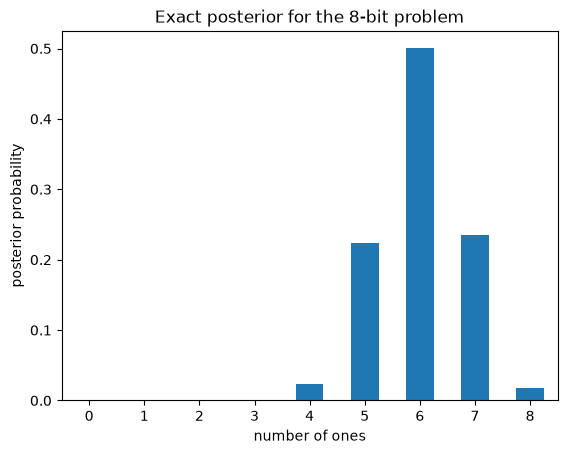

In [9]:

ax = pmf8.plot.bar(x='value', y='prob', legend=False, rot=0)
ax.set_xlabel('number of ones')
ax.set_ylabel('posterior probability')
ax.set_title('Exact posterior for the 8-bit problem')
plt.show()



## What this adds relative to LW/SMC/MH

The evaluator did not change.  Only the controller changed.

- LW: answer each `sample` with one random draw; accumulate observe scores.
- SMC: keep many paused machines; resample at synchronized observes.
- SSMH: replay traces by address, resampling one site at a time.
- Enumeration: fork the continuation at finite discrete `sample` sites and aggregate all completed traces exactly.

The limitation is also clear from the controller: exact enumeration needs finite support. A program containing `(sample (normal ...))` has no finite branch list for `sample`, so this enumerator correctly refuses to run it.
